In [116]:
!pip install -q pyvi
!pip install -q underthesea
!pip install -q py-vncorenlp

# A.BỘ DỮ LIỆU UIT-VSFC (Phân loại văn bản)

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import seaborn as sns
import unicodedata
import requests

## 1. Kiểm tra cấu trúc bộ dữ liệu

In [118]:
df_train = pd.read_parquet('/content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3/UIT-VN_Student_FB/train/train.parquet')
df_test = pd.read_parquet('/content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3/UIT-VN_Student_FB/test/test.parquet')
df_dev = pd.read_parquet('/content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3/UIT-VN_Student_FB/validation/validation.parquet')

In [119]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11426 entries, 0 to 11425
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentence   11426 non-null  object
 1   sentiment  11426 non-null  int64 
 2   topic      11426 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 267.9+ KB


In [120]:
print(f"Số lượng mẫu tập training là: {len(df_train)}")
print(f"Số lượng mẫu tập dev là: {len(df_dev)}")
print(f"Số lượng mẫu tập test là: {len(df_test)}")

Số lượng mẫu tập training là: 11426
Số lượng mẫu tập dev là: 1583
Số lượng mẫu tập test là: 3166


In [121]:
df_train.head(10)

,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0
5,"giảng viên đảm bảo thời gian lên lớp , tích cự...",2,0
6,"em sẽ nợ môn này , nhưng em sẽ học lại ở các h...",1,3
7,"thời lượng học quá dài , không đảm bảo tiếp th...",0,1
8,"nội dung môn học có phần thiếu trọng tâm , hầu...",0,1
9,cần nói rõ hơn bằng cách trình bày lên bảng th...,0,1


## 2. Phân tích phân bố nhãn (Label Distribution)


In [122]:
labels_map = {0: "TIÊU CỰC 😡", 1: "TRUNG TÍNH 😐", 2: "TÍCH CỰC 😍"}

# Hàm convert
def map_labels(series):
    return series.map(labels_map)

# Đếm số lượng
train_counts = df_train['sentiment'].value_counts().sort_index()
dev_counts   = df_dev['sentiment'].value_counts().sort_index()
test_counts  = df_test['sentiment'].value_counts().sort_index()

# In số lượng
print("=== TRAIN ===")
for k, v in train_counts.items():
    print(f"{labels_map[k]}: {v}")

print("\n=== DEV ===")
for k, v in dev_counts.items():
    print(f"{labels_map[k]}: {v}")

print("\n=== TEST ===")
for k, v in test_counts.items():
    print(f"{labels_map[k]}: {v}")

=== TRAIN ===
TIÊU CỰC 😡: 5325
TRUNG TÍNH 😐: 458
TÍCH CỰC 😍: 5643

=== DEV ===
TIÊU CỰC 😡: 705
TRUNG TÍNH 😐: 73
TÍCH CỰC 😍: 805

=== TEST ===
TIÊU CỰC 😡: 1409
TRUNG TÍNH 😐: 167
TÍCH CỰC 😍: 1590


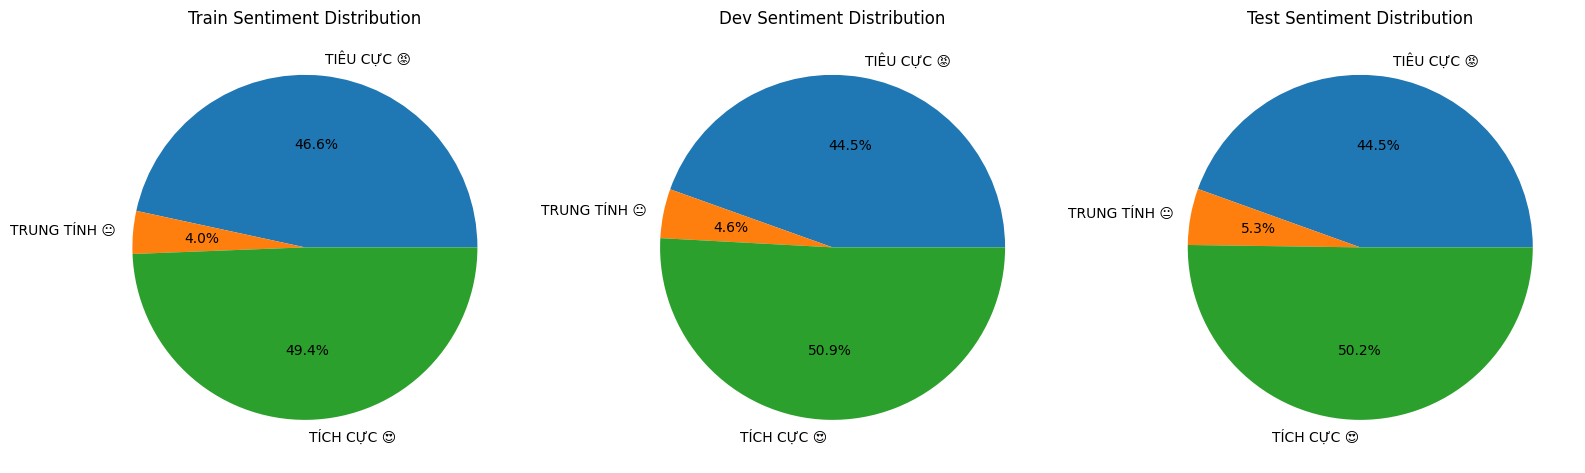

In [123]:
# Mapping sang text cho pie
train_labels = map_labels(train_counts.index)
dev_labels   = map_labels(dev_counts.index)
test_labels  = map_labels(test_counts.index)

# Vẽ 3 pie
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].pie(train_counts, labels=train_labels, autopct='%1.1f%%')
axes[0].set_title('Train Sentiment Distribution')

axes[1].pie(dev_counts, labels=dev_labels, autopct='%1.1f%%')
axes[1].set_title('Dev Sentiment Distribution')

axes[2].pie(test_counts, labels=test_labels, autopct='%1.1f%%')
axes[2].set_title('Test Sentiment Distribution')

plt.tight_layout()
plt.show()


Dữ liệu bị mất cân bằng nhãn nghiêm trọng cho lớp trung tính, chỉ đạt `4% - 5.3%`

## 3. Phân tích độ dài câu

### a. Tính min, max, mean độ dài câu (tính theo số từ)

In [124]:
# Tính số từ
df_train['num_words'] = df_train['sentence'].apply(lambda x: len(str(x).split()))
df_dev['num_words']   = df_dev['sentence'].apply(lambda x: len(str(x).split()))
df_test['num_words']  = df_test['sentence'].apply(lambda x: len(str(x).split()))

def stats(df, name):
    print(f"=== {name} ===")
    print("Min:", df['num_words'].min())
    print("Max:", df['num_words'].max())
    print("Mean:", df['num_words'].mean())
    print("----------------------------------")

stats(df_train, "TRAIN")
stats(df_dev, "DEV")
stats(df_test, "TEST")

=== TRAIN ===
Min: 2
Max: 159
Mean: 14.308769473131454
----------------------------------
=== DEV ===
Min: 2
Max: 161
Mean: 13.67150979153506
----------------------------------
=== TEST ===
Min: 2
Max: 98
Mean: 14.2207833228048
----------------------------------


### b. Histogram độ dài câu

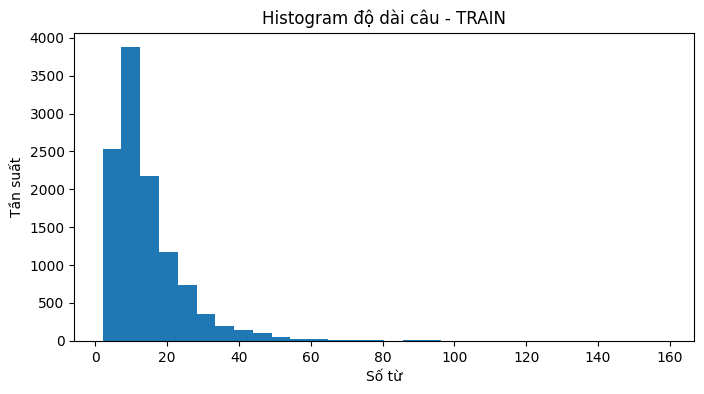

In [125]:
plt.figure(figsize=(8,4))
plt.hist(df_train['num_words'], bins=30)
plt.title("Histogram độ dài câu - TRAIN")
plt.xlabel("Số từ")
plt.ylabel("Tần suất")
plt.show()

### c. Tương quan độ dài câu và nhãn

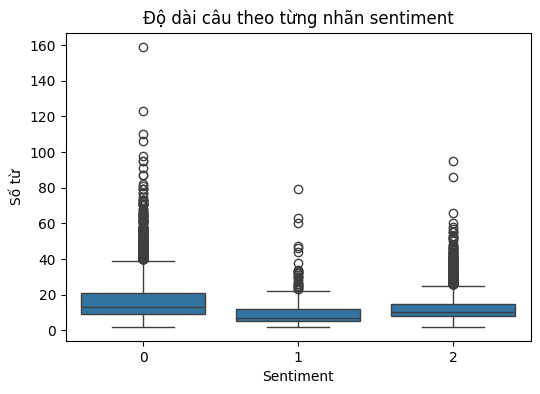

In [126]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_train['sentiment'], y=df_train['num_words'])
plt.title("Độ dài câu theo từng nhãn sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Số từ")
plt.show()

## 4. Thống kê từ vựng

### a. Đếm từ & phát hiện từ “lạ” của DEV/TEST so với TRAIN

In [127]:
def get_unique_words(df):
    # Nối toàn bộ câu thành 1 chuỗi dài, chuyển về chữ thường
    text = " ".join(df['sentence'].astype(str)).lower()
    # Dùng regex để bắt các từ (loại bỏ dấu câu)
    words = re.findall(r'\w+', text)
    return set(words)  # Trả về tập hợp các từ không trùng lặp (UNIQUE)

# --- Thực thi ---
train_vocab = get_unique_words(df_train)
dev_vocab   = get_unique_words(df_dev)
test_vocab  = get_unique_words(df_test)

print("=== UNIQUE WORD COUNTS (Updated with Regex) ===")
print("Train unique words:", len(train_vocab))
print("Dev unique words:  ", len(dev_vocab))
print("Test unique words: ", len(test_vocab))

# Tìm từ OOV (Out-Of-Vocabulary)
dev_oov = dev_vocab - train_vocab
test_oov = test_vocab - train_vocab

print(f"\n=== DEV OOV: {len(dev_oov)} từ ===")
print("Ví dụ:", list(dev_oov)[:10])

print(f"\n=== TEST OOV: {len(test_oov)} từ ===")
print("Ví dụ:", list(test_oov)[:10])

=== UNIQUE WORD COUNTS (Updated with Regex) ===
Train unique words: 2486
Dev unique words:   1148
Test unique words:  1568

=== DEV OOV: 108 từ ===
Ví dụ: ['wzjwz170', 'k6', 'wzjwz10', 'lun', 'rách', 'sinn', 'mcu', 'khiển', 'nọ', 'this']

=== TEST OOV: 262 từ ===
Ví dụ: ['thướng', 'khmtdotuitdotedudotvn', 'wzjwz320', 'vắn', '10h15', 'heapsort', 'chuyền', 'wzjwz136', 'wzjwz188', 'wzjwz172']


### b. Top 20 từ xuất hiện nhiều nhất

In [128]:
def top_words(df, name, n=20):
    text = " ".join(df['sentence'].astype(str)).lower()
    words = re.findall(r'\w+', text)
    counter = Counter(words)
    print(f"=== TOP {n} WORDS ({name}) ===")
    for w, c in counter.most_common(n):
        print(w, ":", c)
    print("----------------------------------")

top_words(df_train, "TRAIN", n=20)

=== TOP 20 WORDS (TRAIN) ===
viên : 4803
giảng : 3711
dạy : 3156
thầy : 3095
sinh : 3082
học : 2940
bài : 2336
tình : 2266
không : 2177
và : 2068
có : 2031
rất : 1961
nhiệt : 1931
cho : 1735
hiểu : 1730
nhiều : 1622
tập : 1455
dễ : 1438
thực : 1431
cô : 1202
----------------------------------


### c. Top từ theo từng nhãn (có tương quan với nhãn)

In [129]:
def words_by_label(df, label, top_n=20):
    subset = df[df['sentiment'] == label]['sentence']
    text = " ".join(subset.astype(str)).lower()
    words = re.findall(r'\w+', text)
    counter = Counter(words)

    print(f"=== LABEL {label} ({len(subset)} câu) ===")
    for w, c in counter.most_common(top_n):
        print(f"{w}: {c}")
    print("----------------------------------")

# Chạy cho 3 nhãn
for label in sorted(df_train['sentiment'].unique()):
    words_by_label(df_train, label, top_n=5)

=== LABEL 0 (5325 câu) ===
viên: 2178
học: 1817
không: 1814
sinh: 1447
giảng: 1445
----------------------------------
=== LABEL 1 (458 câu) ===
không: 116
có: 101
thầy: 94
em: 92
học: 85
----------------------------------
=== LABEL 2 (5643 câu) ===
viên: 2555
giảng: 2219
tình: 2135
dạy: 2135
nhiệt: 1843
----------------------------------


> => Các từ chung chung như `giảng, viên, học, có, khoong` là các từ thường xuất hiện ở các câu, đây có thể xem là 1 dạng stop word trong bài toán phân loại cảm xúc bằng thống kê vì không đưa được ý nghĩa phân loại lớn

### d. Có cần làm preprocessing không?

=> Có và Phần tiếp theo sẽ đưa ra bằng chứng

## 5. Tiền xử lý dữ liệu

## **Bước 1: Kiểm tra và Chuẩn hóa Unicode (Unicode Normalization)**
>
> Trong tiếng Việt, cùng một ký tự hiển thị (ví dụ: `á`) có thể được máy tính lưu trữ dưới 2 dạng mã hóa khác nhau:
>
>   * **NFC (Dựng sẵn):** `á` (1 ký tự).
>   * **NFD (Tổ hợp):** `a` + `dấu sắc` (2 ký tự).
>
> Sự không nhất quán này sẽ khiến mô hình hiểu nhầm đây là 2 từ khác nhau, làm tăng lượng từ vựng rác (duplicate features). Bước này kiểm tra và đảm bảo toàn bộ dữ liệu được đưa về chuẩn **NFC** thống nhất.


In [130]:
def check_unicode_issue(df, num_rows=500):
    print(f"--- Đang quét {num_rows} dòng đầu tiên của df_train ---")
    count_issues = 0

    for i, text in enumerate(df['sentence'].head(num_rows)):
        text = str(text)

        # Tạo phiên bản chuẩn NFC của dòng này
        text_nfc = unicodedata.normalize('NFC', text)

        # So sánh: Nếu text gốc trong Data khác với bản chuẩn NFC
        # => Data của bạn đang chứa ký tự tổ hợp (hoặc lỗi mã hóa khác)
        if text != text_nfc:
            count_issues += 1
            print(f"\n[PHÁT HIỆN LỖI TẠI DÒNG {i}]")
            print(f"Text gốc:   {text}")
            print(f"Độ dài gốc: {len(text)}")
            print(f"Độ dài NFC: {len(text_nfc)}")

            # Mổ xẻ chi tiết ký tự khác nhau
            # In ra mã Hex để thấy máy tính lưu nó thế nào
            print("Chi tiết mã Hex (Gốc vs NFC):")
            # Chỉ in vài ký tự đầu để so sánh cho gọn
            hex_origin = [hex(ord(c)) for c in text][:10]
            hex_nfc    = [hex(ord(c)) for c in text_nfc][:10]
            print(f" - Gốc: {hex_origin}")
            print(f" - NFC: {hex_nfc}")

            # Chỉ cần tìm thấy 1 lỗi là dừng demo để bạn xem
            break

    if count_issues == 0:
        print("\n=> Tuyệt vời! 500 dòng đầu không có lỗi Unicode (Data đã sạch hoặc đã là NFC).")
    else:
        print(f"\n=> Có lỗi! Máy tính hiểu sai độ dài từ. Cần chạy hàm normalize.")

# Gọi hàm kiểm tra
check_unicode_issue(df_train)

--- Đang quét 500 dòng đầu tiên của df_train ---

=> Tuyệt vời! 500 dòng đầu không có lỗi Unicode (Data đã sạch hoặc đã là NFC).


In [131]:
# để đảm bảo an toàn tuyệt đối cho cả Dev và Test set (có thể đến từ nguồn khác)
df_train['sentence'] = df_train['sentence'].apply(lambda x: unicodedata.normalize('NFC', str(x)))
df_dev['sentence']   = df_dev['sentence'].apply(lambda x: unicodedata.normalize('NFC', str(x)))
df_test['sentence']  = df_test['sentence'].apply(lambda x: unicodedata.normalize('NFC', str(x)))

## **Bước 2: Chuẩn hóa viết thường (Lowercase)**

In [132]:
def get_vocab_set(series, do_lower=False):
    text = " ".join(series.astype(str))
    if do_lower:
        text = text.lower()
    # Chỉ lấy ký tự chữ/số, bỏ qua dấu câu
    return set(re.findall(r'\w+', text))

# 1. Tính số lượng từ vựng hiện tại (Gốc - có cả Hoa và thường)
vocab_original = get_vocab_set(df_train['sentence'], do_lower=False)

# 2. Tính số lượng từ vựng giả định (Nếu lowercase)
vocab_lower = get_vocab_set(df_train['sentence'], do_lower=True)

# 3. So sánh dữ liệu thực tế
print(f"Số từ vựng gốc (Regex): {len(vocab_original)}")
print(f"Số từ vựng sau khi lowercase (Regex): {len(vocab_lower)}")
print(f"=> Giảm được {len(vocab_original) - len(vocab_lower)} từ bị trùng lặp do viết Hoa/thường.")

# 4. Áp dụng (Luôn nên làm cho bài toán này)
df_train['sentence'] = df_train['sentence'].str.lower()
df_dev['sentence']   = df_dev['sentence'].str.lower()
df_test['sentence']  = df_test['sentence'].str.lower()

print("Đã hoàn thành lowercase!")

Số từ vựng gốc (Regex): 2486
Số từ vựng sau khi lowercase (Regex): 2486
=> Giảm được 0 từ bị trùng lặp do viết Hoa/thường.
Đã hoàn thành lowercase!


## **Bước 3: Xử lý Lỗi chính tả & Teencode (Manual Correction)**

Ta sẽ dùng 1 tập từ điển tiếng việt để lọc ra các từ không chính thống của tiếng việt (viết tắt, viết sai,...) Tuy nhiên để không làm mất các thuật ngữ tiếng anh, cái mà khá phổ biến trong data của 1 trường về CNTT (html, sql,...) ta sẽ tạo 1 white_list để bỏ qua nếu gặp. White_list này được tổng hợp thủ công bằng cách chạy nhiều lần code bên dưới và thêm vào

In [133]:
# 1. Tải từ điển
url = "https://raw.githubusercontent.com/duyet/vietnamese-wordlist/master/Viet74K.txt"
response = requests.get(url)
vn_dict_data = response.text.splitlines()

# 2. Xử lý Từ điển: Tách từ ghép thành từ đơn (Single Syllables)
# Thay vì lưu "thắc mắc", ta lưu {"thắc", "mắc"}
vn_dict_single = set()
for compound_word in vn_dict_data:
    # Chuẩn hóa Unicode + Lowercase
    norm_word = unicodedata.normalize('NFC', compound_word.strip().lower())
    # Tách ra từng tiếng và đưa vào set
    for syllable in norm_word.split():
        vn_dict_single.add(syllable)

print(f"Đã xây dựng bộ từ điển đơn âm: {len(vn_dict_single)} từ.")

# 3. Cập nhật Whitelist (Bổ sung từ kết quả OOV bạn vừa thấy)
# Bao gồm: Tech terms + Token cảm xúc + Từ tiếng Anh trong trường học
tech_whitelist = {
    # 1. Tech terms
    "sql", "oop", "dsa", "csdl", "nmm", "windows", "photo", "update",
    "html", "css", "js", "javascript", "java", "python", "c", "c++", "php",
    "android", "ios", "xml", "json", "react", "node", "angular", "web",
    "website", "app", "application", "server", "client", "database",
    "api", "code", "coding", "debug", "fix", "bug", "error", "wifi",
    "internet", "lan", "slide", "powerpoint", "file", "folder", "link",
    "url", "laptop", "google", "copy", "facebook", "project", "csharp", "youtube",
    "online", "wireshark", "it", "linux", "uit", "oracle", "max", "is",
    "silde", "phone", "pro", "cplusplus", "framework", "router", "pdf",
    "full", "odoo", "ubuntu", "trigger", "scrum", "paste",

    # 2. Token cảm xúc/đặc biệt
    "colonsmile", "colonsad", "colonsurprise", "colonlove", "colonsmilesmile",
    "coloncontemn", "colonbigsmile", "coloncc", "colonsmallsmile",
    "coloncolon", "colonlovelove", "colonhihi", "colonsadcolon",
    "colondoublesurprise", "doubledot", "vdotv", "dotdotdot", "fraction",
    "dot", "good", "funny",

    # 3. English học đường / hệ thống
    "lab", "deadline", "wecode", "moodle", "course", "courses", "forum", "game",
    "visual", "studio", "clip", "toeic", "ielts", "kit", "up", "check",
    "log", "out", "source", "training", "mail", "demo", "speaking",
    "listening", "daa", "email", "post", "win", "very", "share", "reply",
    "team", "upload", "grammar", "like", "boss", "rep", "topic", "chat",
}


# 4. Chạy lại bộ lọc OOV
all_text = pd.concat([df_train['sentence'], df_dev['sentence'], df_test['sentence']])
all_words = " ".join(all_text.astype(str)).lower().split()
word_counts = Counter(all_words)

suspicious_words = []
for w, c in word_counts.items():
    if w.isalpha():
        # Kiểm tra: Không nằm trong từ điển đơn âm VÀ Không nằm trong Whitelist
        if (w not in vn_dict_single) and (w not in tech_whitelist):
            suspicious_words.append((w, c))

# Sắp xếp
suspicious_words.sort(key=lambda x: x[1], reverse=True)

print(f"\n=== TÌM THẤY {len(suspicious_words)} TỪ KHẢ NGHI THỰC SỰ ===")
print("--- Top 30 (Dùng list này để cập nhật teencode_dict lần cuối) ---")
for w, c in suspicious_words[:30]:
    print(f"{w}: {c}")

Đã xây dựng bộ từ điển đơn âm: 11057 từ.

=== TÌM THẤY 328 TỪ KHẢ NGHI THỰC SỰ ===
--- Top 30 (Dùng list này để cập nhật teencode_dict lần cuối) ---
đươc: 6
hiễu: 5
nghành: 4
chổ: 4
thưc: 4
hiều: 4
patin: 4
show: 3
hiêu: 3
nhiểu: 3
đc: 3
for: 2
servlet: 2
gủi: 2
ngiêm: 2
nhiêt: 2
them: 2
ida: 2
soft: 2
gb: 2
silverlight: 2
lap: 2
lỳ: 2
pattern: 2
turnitindotcom: 2
prolog: 2
cassette: 2
cdio: 2
love: 2
word: 2


> Phân tích danh sách từ OOV tần suất cao (Top 30) cho thấy tồn tại nhiều lỗi chính tả tiếng Việt phổ biến (sai dấu hỏi/ngã như `hiễu`, `chổ`) và từ viết tắt (`đc`). Các từ vựng tiếng Anh chuyên ngành (`servlet`, `pattern`...) là hợp lệ nên giữ nguyên.

>  => Xây dựng từ điển ánh xạ (Mapping Dictionary) để sửa các lỗi chính tả tiếng Việt xuất hiện nhiều nhất, bỏ qua các từ xuất hiện ít hoặc từ chuyên ngành.


In [134]:
# 1. Từ điển sửa lỗi (Chỉ map những từ sai chính tả trong Top 30 OOV)
correction_dict = {
    # Sai dấu hỏi/ngã/nặng
    "hiễu": "hiểu", "hiều": "hiểu", "hiêu": "hiểu",
    "chổ": "chỗ",
    "nhiểu": "nhiều",
    "ngiêm": "nghiêm",
    "nhiêt": "nhiệt",
    "thưc": "thực",
    "nghành": "ngành",
    "gủi": "gửi",
    "lỳ": "lì",
    "tâp": "tập",

    # Viết tắt/Teencode
    "đươc": "được", "đc": "được",

    # (Các từ tiếng Anh như 'show', 'servlet'... không map -> Giữ nguyên)
}

# 2. Pipeline xử lý
def manual_correction(text):
    text = str(text).lower()

    # Xử lý Mã ẩn danh & Số & Dấu câu
    text = re.sub(r'wzjwz\d+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s!?]', ' ', text)

    words = text.split()
    cleaned_words = []
    for w in words:
        # Nếu từ nằm trong danh sách lỗi -> Sửa
        if w in correction_dict:
            cleaned_words.append(correction_dict[w])
        # Giữ lại từ đúng hoặc từ tiếng Anh (len > 1) và dấu câu cảm xúc
        elif len(w) > 1 or w in ['?', '!']:
            cleaned_words.append(w)

    return " ".join(cleaned_words)

# 3. Áp dụng
df_train['clean_sentence'] = df_train['sentence'].apply(manual_correction)
df_dev['clean_sentence']   = df_dev['sentence'].apply(manual_correction)
df_test['clean_sentence']  = df_test['sentence'].apply(manual_correction)

print("Đã hoàn tất sửa lỗi chính tả thủ công!")
# Kiểm tra nhanh
df_train[df_train['sentence'].str.contains('hiễu', na=False)][['sentence', 'clean_sentence']].head(2)

Đã hoàn tất sửa lỗi chính tả thủ công!


,sentence,clean_sentence
135,cách giảng dạy của thầy rất hay và có phần dễ ...,cách giảng dạy của thầy rất hay và có phần dễ ...
643,điều em hài lòng nhất đó là thầy với tốc độ ph...,điều em hài lòng nhất đó là thầy với tốc độ ph...


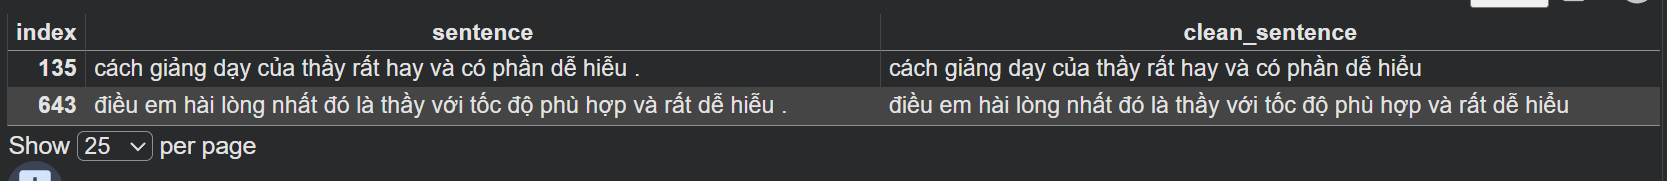

## **Bước 4: Tách từ**

## a. Pyvi

In [135]:
from pyvi import ViTokenizer

sample_text = "Tôi học sinh học rất vui với bao bạn bè và thầy cô!"
print(f"pyvi: {ViTokenizer.tokenize(sample_text)}")

pyvi: Tôi học_sinh_học rất vui với bao bạn_bè và thầy cô !


## b. underthesea

In [136]:
from underthesea import word_tokenize

sample_text = "Tôi học sinh học rất vui với bao bạn bè và thầy cô!"
print(f"underthesea: {word_tokenize(sample_text, format='text')}")

underthesea: Tôi học_sinh_học rất vui với bao bạn_bè và thầy_cô !


## c. VncoreNLP

In [137]:
import os
import py_vncorenlp

# 1. Cấu hình đường dẫn
MODEL_DIR = '/content/VnCoreNLP'
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

# 2. Tải model nếu chưa có
if not os.path.exists(os.path.join(MODEL_DIR, 'VnCoreNLP-1.2.jar')):
    print("Downloading VnCoreNLP...")
    py_vncorenlp.download_model(save_dir=MODEL_DIR)

# 3. Load model (Chỉ load nếu chưa có trong globals để tránh lỗi VM)
if 'vncore_model' not in globals():
    print("Initializing VnCoreNLP...")
    vncore_model = py_vncorenlp.VnCoreNLP(save_dir=MODEL_DIR, annotators=["wseg"])
    print("VnCoreNLP loaded.")
else:
    print("VnCoreNLP is already ready.")

VnCoreNLP is already ready.


In [138]:
output = vncore_model.word_segment(sample_text)
print(f"VnCoreNLP: {output[0]}")

VnCoreNLP: Tôi học_sinh học rất vui với bao bạn_bè và thầy_cô !


> Ta thấy rằng sự nhập nhằng ở đây giữa `học sinh` và `sinh học` . Các thư viện như `pivy`, `underthesea`không xử lý được và tạo ra token ngoài tập từ điển. Trong khi `vncorenlp` thì tách thành công nhưng chưa đúng hàm ý.

## Tách từ và Xuất dữ liệu (Tokenization & Export)

Sử dụng thư viện `underthesea` để tách từ và lưu kết quả vào thư mục `preprocessed_UIT-VN_Student_FB`.

In [139]:
import os
from underthesea import word_tokenize
from tqdm import tqdm

# 1. Cấu hình đường dẫn
# Đường dẫn gốc tới bài Lab
BASE_DIR = '/content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3'

# Tên folder chứa dữ liệu output (Tạo folder bao quanh 3 file)
OUTPUT_FOLDER_NAME = 'preprocessed_UIT-VN_Student_FB'
OUTPUT_DIR = os.path.join(BASE_DIR, OUTPUT_FOLDER_NAME)

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(OUTPUT_DIR):
    print(f"Đang tạo thư mục output: {OUTPUT_DIR}")
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Hàm tách từ
def apply_underthesea(text):
    return word_tokenize(str(text), format='text')

# 3. Thực thi tách từ
tqdm.pandas()
print("Đang thực hiện tách từ...")

df_train['segmented_sentence'] = df_train['clean_sentence'].progress_apply(apply_underthesea)
df_dev['segmented_sentence']   = df_dev['clean_sentence'].progress_apply(apply_underthesea)
df_test['segmented_sentence']  = df_test['clean_sentence'].progress_apply(apply_underthesea)

# 4. Xuất file vào folder đã tạo
print(f"\nĐang lưu 3 file vào: {OUTPUT_DIR}")

df_train.to_csv(os.path.join(OUTPUT_DIR, 'train_processed.csv'), index=False)
df_dev.to_csv(os.path.join(OUTPUT_DIR, 'dev_processed.csv'), index=False)
df_test.to_csv(os.path.join(OUTPUT_DIR, 'test_processed.csv'), index=False)

print("Hoàn tất!")
print(f"Kiểm tra file tại: {OUTPUT_DIR}")
print(df_train[['clean_sentence', 'segmented_sentence']].head())

Đang tạo thư mục output: /content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3/preprocessed_UIT-VN_Student_FB
Đang thực hiện tách từ...


100%|██████████| 3166/3166 [00:02<00:00, 1210.02it/s]



Đang lưu 3 file vào: /content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3/preprocessed_UIT-VN_Student_FB
Hoàn tất!
Kiểm tra file tại: /content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3/preprocessed_UIT-VN_Student_FB
                                      clean_sentence  \
0                            slide giáo trình đầy đủ   
1         nhiệt tình giảng dạy gần gũi với sinh viên   
2                 đi học đầy đủ full điểm chuyên cần   
3  chưa áp dụng công nghệ thông tin và các thiết ...   
4  thầy giảng bài hay có nhiều bài tập ví dụ ngay...   

                                  segmented_sentence  
0                            slide giáo_trình đầy_đủ  
1         nhiệt_tình giảng_dạy gần_gũi với sinh_viên  
2                 đi học đầy_đủ full_điểm chuyên cần  
3  chưa áp_dụng công_nghệ_thông_tin và các thiết_...  
4  thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...  
